In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# PARAMETRI GLOBALI
# CREDO, CHE NEL CONTESTO DI SVILUPPARE CODICE MEGLIO SCALABILE
# , QUALITà LA QUALE CREDO DEBBA STARE ALLA BASE DI OGNI BUONA 
# SIMULAZIONE QUESTO FOGLIO DEBBA CONTENERE MENO RIGHE DI CODICE
# POSSIBILE.
# (SCRIVO COME SE QUALCUNO LEGGESSE MAI QUESTE CAZZATE)
N = 20
J = 1
K = 1 # costante adimensionale di Boltzman

/tmp/ipykernel_6046/3908792702.py:14: RuntimeWarning: invalid value encountered in scalar divide
  p = np.exp(-DH(LATTICE,i,j,B)/(K*T))
/tmp/ipykernel_6046/3908792702.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  p = np.exp(-DH(LATTICE,i,j,B)/(K*T))


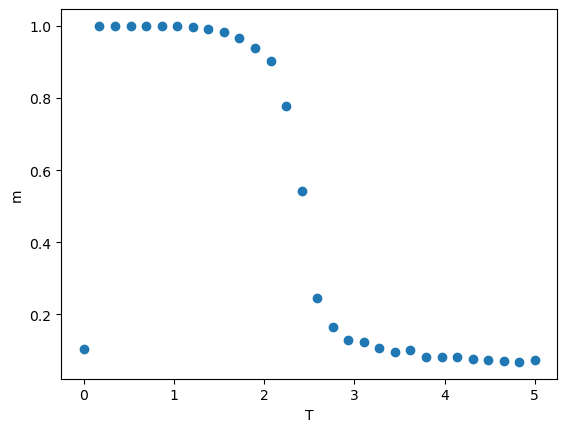

In [ ]:


def DH(LATTICE,i,j,B):
    x1 = i
    y1 = j
    x2 = (i + 1)%N 
    y2 = (j + 1)%N
    x3 = (i - 1)%N
    y3 = (j - 1)%N

    return -2*J*LATTICE[x1][y1]*(LATTICE[x2][y1] + LATTICE[x1][y2] + LATTICE[x3][y1] + LATTICE[x1][y3]) - 2*B*LATTICE[x1][y1]

def metropolis_step(LATTICE,T,B,i,j):
    LATTICE[i][j] = -LATTICE[i][j]
 
    p = np.exp(-DH(LATTICE,i,j,B)/(K*T))
    if(p >= np.random.random()):
        return LATTICE
    else:
        LATTICE[i][j] = -LATTICE[i][j]
        return LATTICE


# Sono interessato a fare vari esperimenti al variare di
# Temperatura e modulo del campo magnetico.
def esperimento(LATTICE, T, B,n_equilibrio = 500, n_misure=200):
    TEMP_LATTICE = LATTICE

    # Equilibrio termico
    for _ in range(n_equilibrio):
        for i in range(N):
            for j in range(N):
                metropolis_step(LATTICE,T,B,i,j)
    
    misure = []
    for _ in range(n_misure):
        for i in range(N):
            for j in range(N):
                TEMP_LATTICE = metropolis_step(TEMP_LATTICE,T,B,i,j)
        misure.append(abs(np.mean(TEMP_LATTICE)))

    return np.mean(misure),TEMP_LATTICE

LATTICE = np.random.choice([-1,1],size=(N,N))
Ts = np.linspace(0, 5.0, 30)
ms = [esperimento(LATTICE, T, 0)[0] for T in Ts]

plt.scatter(Ts, ms)
plt.xlabel("T")
plt.ylabel("m")
plt.show()


    